In [1]:
import cv2
import os
import numpy as np
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import skimage.measure
from skimage.measure import label

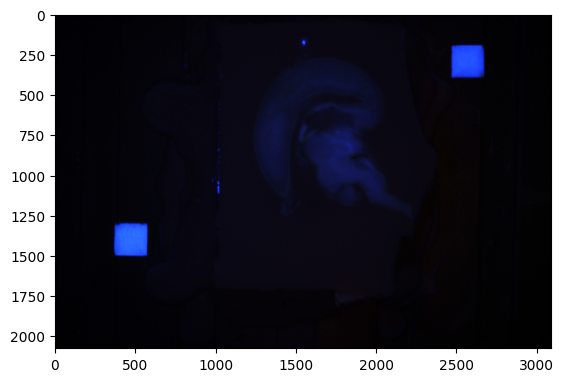

In [2]:
img = mpimg.imread('/home/projects/registration/Data/BFI_registration/222/BFI/B_222-ST_BFI-SE_936_original.jpg')
plt.imshow(img)
plt.show()

In [3]:
print('image dimension:', img.shape)

image dimension: (2076, 3088, 3)


In [4]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3],[0.29, 0.58, 0.11])

gray = rgb2gray(img)

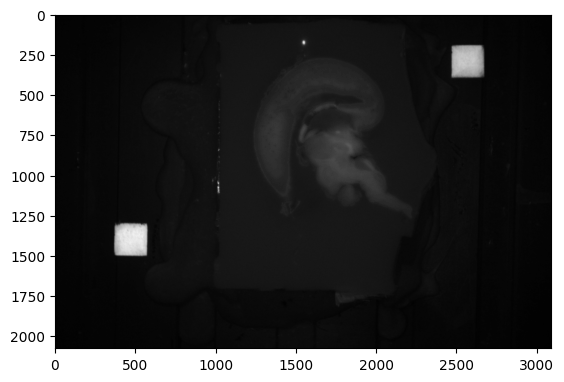

In [5]:
plt.imshow(gray, cmap =plt.get_cmap('gray'))
plt.show()

# Fiducial Removal

(2076, 3088, 3)


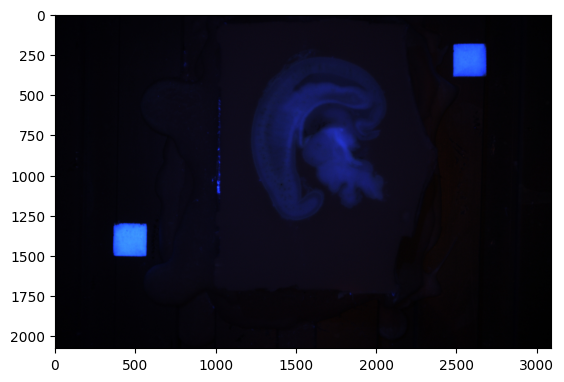

In [6]:
image_path = '/home/projects/registration/Data/BFI_registration/222/BFI/B_222-ST_BFI-SE_1011_original.jpg'
bgr_image = cv2.imread(image_path) #original image, cv.imread reads in bgr format
print(bgr_image.shape)
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB) #BGR to RGB conversion since while using imshow it uses rgb format
bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2]) #taking transpose of original bgr image and using it for further processing
plt.imshow(rgb_image, cmap='gray')
#plt.imshow(bgr_image_transpose)


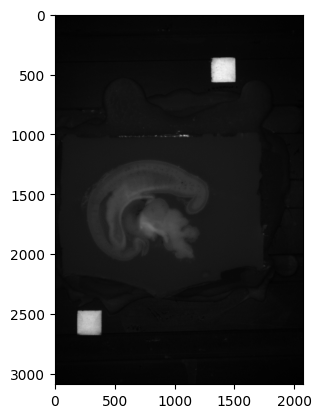

In [7]:
# converting bgr to Ycbcr
# converts the image bgr_image_transpose from BGR color space to YCrCb color space
ycbcr_image = cv2.cvtColor(bgr_image_transpose, cv2.COLOR_BGR2YCrCb) 
gray_image = ycbcr_image[:,:,0]  # selecting all rows and columns & extracts the Y channel
plt.imshow(gray_image, cmap = 'gray')


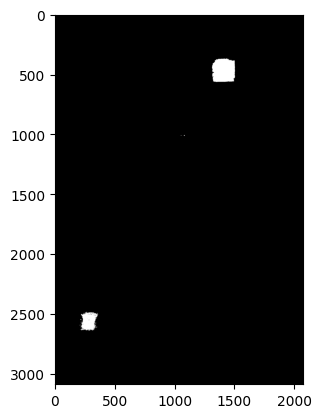

In [8]:
thres = np.max(gray_image) - 0.3*(np.max(gray_image))
ret, thresh1 = cv2.threshold(gray_image, thres,np.max(gray_image), cv2.THRESH_BINARY) # binary threshold
plt.imshow(thresh1, cmap='gray')

# np.max(gray_image): returns the maximum pixel value in the gray_image
# np.max(gray_image) - 0.3*(np.max(gray_image)): This expression calculates a threshold value that is 30% less than the 
# maximum pixel value in the gray_image ie,= 0.7×max_val

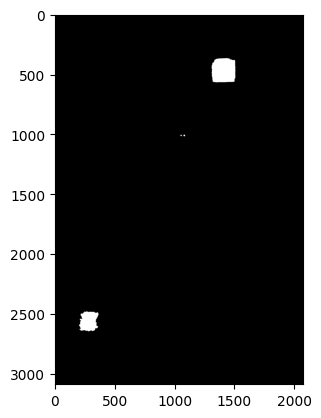

In [9]:
#Step2 : Dilate it by square structural element kernel (7,7), also perform morphological close operation
element = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7)) # creates a rectangular structuring element (kernel) of size 7x7
dilate1 = cv2.dilate(thresh1, element, iterations = 1) # Dilation adds pixels to the boundaries, =1 means dilation operation is performed

kernel = np.ones((7, 7), np.uint8) # Adjust the kernel size as needed
mask_image_closed = cv2.morphologyEx(dilate1, cv2.MORPH_CLOSE, kernel) # used to close small holes or gaps in the object
plt.imshow(mask_image_closed , cmap='gray') 

Number of labels in /home/projects/registration/Data/BFI_registration/222/BFI/B_222-ST_BFI-SE_1011_original.jpg: 4
36760.0
168.0
113.0
21047.0
Top 2 regions by area:
Region 1 - Area: 36760.0
Region 2 - Area: 21047.0


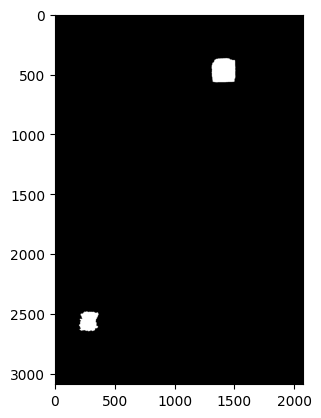

In [10]:
#Step3 : Use region properties, pixel count/ area; sort the areas based on area/pixel count, get the top 2 areas
# Label the connected components in the mask-------method 1
# skimage.measure.label : labels connected regions in a binary image
# connectivity=2 : pixels are connected if they share a face, edge, or corner
labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
print(f"Number of labels in {image_path}: {count}")
regions = skimage.measure.regionprops(labeled_image)
for prop in regions:
    print(prop.area)

# sort and get top 2 maximum area 
# Sort regions by area in descending order
regions.sort(key=lambda x: x.area, reverse=True)

# Print areas of the top 2 regions
print("Top 2 regions by area:")
for i in range(min(2, len(regions))):  # Ensure we only print up to top 2 regions
    print(f"Region {i + 1} - Area: {regions[i].area}")

# Create an image containing only the top 2 regions by area
top_regions = np.zeros_like(labeled_image) # empty image (all zeros) with the same shape as the labeled image.
for i in range(min(2, len(regions))):  # Ensure we only select up to top 2 regions
    top_regions[labeled_image == regions[i].label] = 1

plt.imshow(top_regions, cmap='gray')

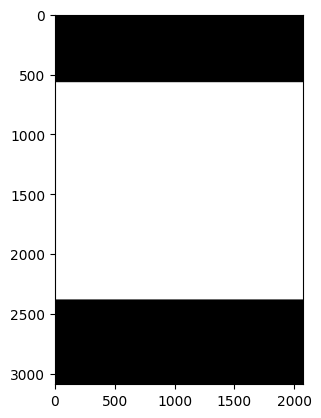

In [11]:
# Working code - some more fiducials are there in the bottom side

# Find all non-zero points (pixels) in the binary image (masked_image)
pixelpointsCV_fid = cv2.findNonZero(top_regions)

# Extract the x and y coordinates of the non-zero pixels
x_indices = pixelpointsCV_fid[:, 0, 0]  # x-coordinates (column indices)
y_indices = pixelpointsCV_fid[:, 0, 1]  # y-coordinates (row indices)

# Calculate the mid-point to separate top-right and bottom-left regions
mid_x = top_regions.shape[1] // 2
mid_y = top_regions.shape[0] // 2

# Extract indices for the top-right region
top_right_indices = np.where((x_indices > mid_x) & (y_indices < mid_y))

# Extract indices for the bottom-left region
bottom_left_indices = np.where((x_indices < mid_x) & (y_indices > mid_y))

# Get the maximum x index in the top-right region
max_x_top_right = np.max(y_indices[top_right_indices])

# Get the minimum x index in the bottom-left region
min_x_bottom_left = np.min(y_indices[bottom_left_indices]-100)

# Create a new mask and apply the regions
new_mask = np.zeros(top_regions.shape)
new_mask[0:max_x_top_right, :] = 1
new_mask[min_x_bottom_left:, :] = 1

# Visualize the result
plt.imshow(1 - new_mask, cmap='gray')
plt.show()


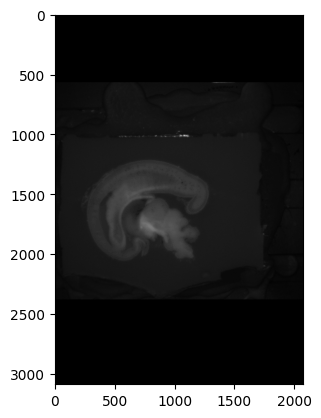

In [12]:
#Step8: ElementWise multiply mask for original section
new_original_image = np.multiply(gray_image, 1 - new_mask) 
plt.imshow(new_original_image, cmap='gray')

In [13]:
# Apply the same mask to Cr and Cb channels and set neutral values to 128 where new_mask =1
ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
ycbcr_image[:,:,0] = new_original_image

(2076, 3088, 3)


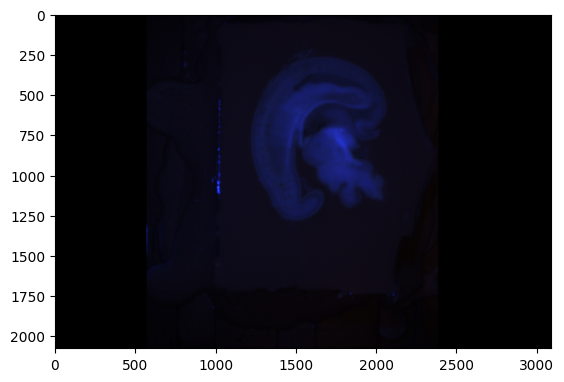

In [14]:
new_bgr_image = cv2.cvtColor(ycbcr_image, cv2.COLOR_YCrCb2BGR)
output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
print(output_bgr_image_transpose.shape)
plt.imshow(cv2.cvtColor(output_bgr_image_transpose, cv2.COLOR_BGR2RGB)) #to show in plot we change bgr2rgb only for view purpose

# Writing as a Function

In [ ]:
import cv2
import numpy as np
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import skimage.measure
from skimage.measure import label


image_path = '/home/projects/registration/Data/BFI_registration/222/BFI'
bgr_image = cv2.imread(image_path) #original image, cv.imread reads in bgr format
print(bgr_image.shape)
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB) #BGR to RGB conversion since while using imshow it uses rgb format
bgr_image_transpose = np.transpose(bgr_image, axes=[1,0,2]) #taking transpose of original bgr image and using it for further processing
plt.imshow(rgb_image, cmap='gray')
#plt.imshow(bgr_image_transpose)

# converting bgr to Ycbcr
# converts the image bgr_image_transpose from BGR color space to YCrCb color space
ycbcr_image = cv2.cvtColor(bgr_image_transpose, cv2.COLOR_BGR2YCrCb) 
gray_image = ycbcr_image[:,:,0]  # selecting all rows and columns & extracts the Y channel
plt.imshow(gray_image, cmap = 'gray')

thres = np.max(gray_image) - 0.3*(np.max(gray_image))
ret, thresh1 = cv2.threshold(gray_image, thres,np.max(gray_image), cv2.THRESH_BINARY) # binary threshold
plt.imshow(thresh1, cmap='gray')

#Step2 : Dilate it by square structural element kernel (7,7), also perform morphological close operation
element = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7)) # creates a rectangular structuring element (kernel) of size 7x7
dilate1 = cv2.dilate(thresh1, element, iterations = 1) # Dilation adds pixels to the boundaries, =1 means dilation operation is performed

kernel = np.ones((7, 7), np.uint8) # Adjust the kernel size as needed
mask_image_closed = cv2.morphologyEx(dilate1, cv2.MORPH_CLOSE, kernel) # used to close small holes or gaps in the object
plt.imshow(mask_image_closed , cmap='gray') 

#Step3 : Use region properties, pixel count/ area; sort the areas based on area/pixel count, get the top 2 areas
# Label the connected components in the mask-------method 1
# skimage.measure.label : labels connected regions in a binary image
# connectivity=2 : pixels are connected if they share a face, edge, or corner
labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
print(f"Number of labels in {image_path}: {count}")
regions = skimage.measure.regionprops(labeled_image)
for prop in regions:
    print(prop.area)

# sort and get top 2 maximum area 
# Sort regions by area in descending order
regions.sort(key=lambda x: x.area, reverse=True)

# Print areas of the top 2 regions
print("Top 2 regions by area:")
for i in range(min(2, len(regions))):  # Ensure we only print up to top 2 regions
    print(f"Region {i + 1} - Area: {regions[i].area}")

# Create an image containing only the top 2 regions by area
top_regions = np.zeros_like(labeled_image) # empty image (all zeros) with the same shape as the labeled image.
for i in range(min(2, len(regions))):  # Ensure we only select up to top 2 regions
    top_regions[labeled_image == regions[i].label] = 1

plt.imshow(top_regions, cmap='gray')

# Find all non-zero points (pixels) in the binary image (masked_image)
pixelpointsCV_fid = cv2.findNonZero(top_regions)

# Extract the x and y coordinates of the non-zero pixels
x_indices = pixelpointsCV_fid[:, 0, 0]  # x-coordinates (column indices)
y_indices = pixelpointsCV_fid[:, 0, 1]  # y-coordinates (row indices)

# Calculate the mid-point to separate top-right and bottom-left regions
mid_x = top_regions.shape[1] // 2
mid_y = top_regions.shape[0] // 2

# Extract indices for the top-right region
top_right_indices = np.where((x_indices > mid_x) & (y_indices < mid_y))

# Extract indices for the bottom-left region
bottom_left_indices = np.where((x_indices < mid_x) & (y_indices > mid_y))

# Get the maximum x index in the top-right region
max_x_top_right = np.max(y_indices[top_right_indices])

# Get the minimum x index in the bottom-left region
min_x_bottom_left = np.min(y_indices[bottom_left_indices]-100)

# Create a new mask and apply the regions
new_mask = np.zeros(top_regions.shape)
new_mask[0:max_x_top_right, :] = 1
new_mask[min_x_bottom_left:, :] = 1

# Visualize the result
plt.imshow(1 - new_mask, cmap='gray')
plt.show()

#Step8: ElementWise multiply mask for original section
new_original_image = np.multiply(gray_image, 1 - new_mask) 
plt.imshow(new_original_image, cmap='gray')

# Apply the same mask to Cr and Cb channels and set neutral values to 128 where new_mask =1
ycbcr_image[:,:,1] = np.where(new_mask == 1, 128, ycbcr_image[:,:,1])
ycbcr_image[:,:,2] = np.where(new_mask == 1, 128, ycbcr_image[:,:,2])
ycbcr_image[:,:,0] = new_original_image

new_bgr_image = cv2.cvtColor(ycbcr_image, cv2.COLOR_YCrCb2BGR)
output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1,0,2])
print(output_bgr_image_transpose.shape)
plt.imshow(cv2.cvtColor(output_bgr_image_transpose, cv2.COLOR_BGR2RGB)) #to show in plot we change bgr2rgb only for view purpose

# Final Integration for fiducial removal as a function

In [ ]:
# unreadable images are skipped in this code
# In stack_bfi_update.py code, it is imported as import cv2 as cv

def remove_fiducials_from_directory(image_dir, output_dir):
    # Ensure the output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Loop over all files in the directory
    for filename in os.listdir(image_dir):
        image_path = os.path.join(image_dir, filename)

        # Check if the file is an image
        if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            print(f"Processing image: {image_path}")
            bgr_image = cv2.imread(image_path)

            # Skip images that cannot be read or are empty
            if bgr_image is None or bgr_image.size == 0:
                print(f"Skipping empty or unreadable image: {image_path}")
                continue

            # Convert BGR to RGB for display
            rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

            # Transpose the image
            bgr_image_transpose = np.transpose(bgr_image, axes=[1, 0, 2])

            # Convert BGR to YCrCb
            ycbcr_image = cv2.cvtColor(bgr_image_transpose, cv2.COLOR_BGR2YCrCb)
            gray_image = ycbcr_image[:, :, 0]

            # Skip if the gray_image is empty
            if gray_image.size == 0:
                print(f"Skipping image due to empty gray channel: {image_path}")
                continue

            # Thresholding
            thres = np.max(gray_image) - 0.3 * (np.max(gray_image))
            ret, thresh1 = cv2.threshold(gray_image, thres, np.max(gray_image), cv2.THRESH_BINARY)

            # Dilate and close operation
            element = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
            dilate1 = cv2.dilate(thresh1, element, iterations=1)
            kernel = np.ones((7, 7), np.uint8)
            mask_image_closed = cv2.morphologyEx(dilate1, cv2.MORPH_CLOSE, kernel)

            # Label the connected regions
            labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
            regions = skimage.measure.regionprops(labeled_image)

            # Sort and get top 2 regions by area
            regions.sort(key=lambda x: x.area, reverse=True)
            top_regions = np.zeros_like(labeled_image)
            for i in range(min(2, len(regions))):
                top_regions[labeled_image == regions[i].label] = 1

            # Find non-zero pixel points
            pixelpointsCV_fid = cv2.findNonZero(top_regions)
            if pixelpointsCV_fid is None:
                print(f"No non-zero pixels found in image: {image_path}")
                continue

            # Extract the x and y coordinates of the non-zero pixels
            x_indices = pixelpointsCV_fid[:, 0, 0]
            y_indices = pixelpointsCV_fid[:, 0, 1]

            # Calculate the mid-point to separate top-right and bottom-left regions
            mid_x = top_regions.shape[1] // 2
            mid_y = top_regions.shape[0] // 2

            # Extract indices for the top-right and bottom-left regions
            top_right_indices = np.where((x_indices > mid_x) & (y_indices < mid_y))
            bottom_left_indices = np.where((x_indices < mid_x) & (y_indices > mid_y))

            # Get the maximum x index in the top-right region
            max_x_top_right = np.max(y_indices[top_right_indices])

            # Get the minimum x index in the bottom-left region
            min_x_bottom_left = np.min(y_indices[bottom_left_indices] - 100)

            # Create a new mask and apply it
            new_mask = np.zeros(top_regions.shape)
            new_mask[0:max_x_top_right, :] = 1
            new_mask[min_x_bottom_left:, :] = 1

            # Apply mask to the original image
            new_original_image = np.multiply(gray_image, 1 - new_mask)
            ycbcr_image[:, :, 0] = new_original_image

            # Apply the mask to Cr and Cb channels and set neutral values to 128
            ycbcr_image[:, :, 1] = np.where(new_mask == 1, 128, ycbcr_image[:, :, 1])
            ycbcr_image[:, :, 2] = np.where(new_mask == 1, 128, ycbcr_image[:, :, 2])

            # Convert back to BGR
            new_bgr_image = cv2.cvtColor(ycbcr_image, cv2.COLOR_YCrCb2BGR)
            output_bgr_image_transpose = np.transpose(new_bgr_image, axes=[1, 0, 2])

            # Save the processed image to the output directory
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, output_bgr_image_transpose)
            print(f"Saved processed image to {output_path}")


# Example usage
#image_directory =  '/home/projects/registration/Data/BFI_registration/222/BFI' # total input
image_directory - '/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/input_'

#output_directory = '/home/projects/registration/Data/BFI_registration/222/BFI/fiducial_removed_222/222/BFI'
output_directory = '/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/fid_removed/222/BFI'

remove_fiducials_from_directory(image_directory, output_directory)


# Cropping image based on ROI

In [ ]:
import os
import cv2
import numpy as np
def process_image(image_path, output_path):
    # Load the image
    bgr_image = cv.imread(image_path)  # original image, cv.imread reads in BGR format
    bgr_image_transpose = np.transpose(bgr_image, axes=[1, 0, 2])  # transpose of original BGR image
    gray = cv.cvtColor(bgr_image_transpose, cv.COLOR_BGR2GRAY)

    # Apply threshold
    thres = np.max(gray) - 0.9 * (np.max(gray))
    ret, thresh1 = cv.threshold(gray, thres, np.max(gray), cv.THRESH_BINARY)

    # Apply morphological operations
    element = cv.getStructuringElement(cv.MORPH_RECT, (7, 7))
    dilate1 = cv.dilate(thresh1, element, iterations=1)
    kernel = np.ones((7, 7), np.uint8)  # Adjust the kernel size as needed
    mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel)

    # Label the connected components in the mask
    labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
    print(f"Number of labels in {image_path}: {count}")
    regions = skimage.measure.regionprops(labeled_image)

    # Sort the regions by area in descending order
    regions.sort(key=lambda x: x.area, reverse=True)

    if len(regions) > 0:
        top_regions = np.zeros_like(labeled_image)
        top_regions[labeled_image == regions[0].label] = 1

        # Get the bounding box coordinates of the top region
        min_row, min_col, max_row, max_col = regions[0].bbox

        # Draw a rectangle around the detected region
        bgr_image1 = cv.cvtColor(mask_image_closed, cv.COLOR_GRAY2BGR) if len(mask_image_closed.shape) == 2 else mask_image_closed
        cv.rectangle(bgr_image1, (min_col, min_row), (max_col, max_row), (255, 0, 0), 2)

        # Crop the RGB image using the bounding box coordinates
        cropped_image = bgr_image_transpose[min_row:max_row, min_col:max_col]
        cropped_image_transpose = np.transpose(cropped_image, axes=[1,0,2]) 

        # Save the cropped image as a JPG file
        output_image_path = os.path.join(output_path, os.path.basename(image_path))
        cv.imwrite(output_image_path, cropped_image_transpose)
        print(f"Cropped image saved to {output_image_path}")

def process_folder(input_folder, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Process each image in the input folder
    for image_filename in os.listdir(input_folder):
        if image_filename.endswith('.jpg'):
            image_path = os.path.join(input_folder, image_filename)
            try:
                process_image(image_path, output_folder)
            except Exception as e:
                print(f"Error processing {image_path}: {e}")



# Example usage
biosampleid = 222
series = 'BFI' 

input_folder = os.path.join('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/fid_removed' , str(biosampleid), series) 
output_folder = os.path.join('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/cropped' , str(biosampleid), series)
process_folder(input_folder, output_folder)

# /home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/fid_removed/222/BFI
#'/home/projects/registration/Data/BFI_registration/222/BFI/fiducial_removed_222 # main dataset



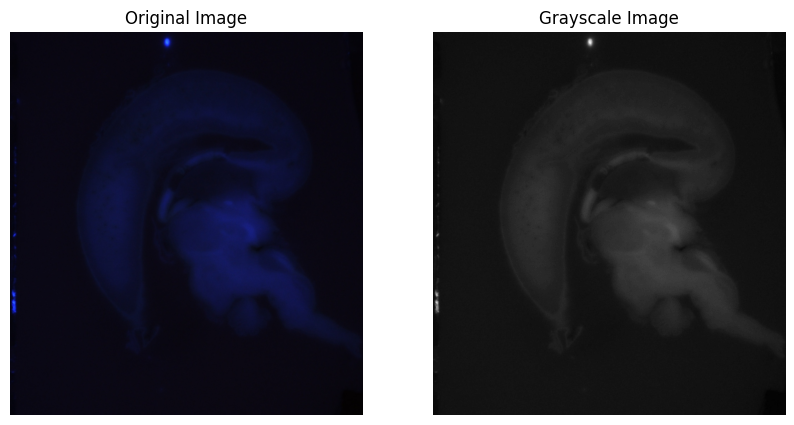

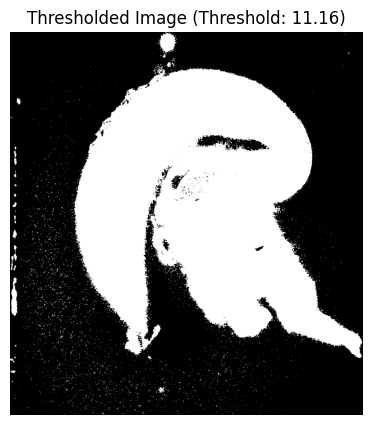

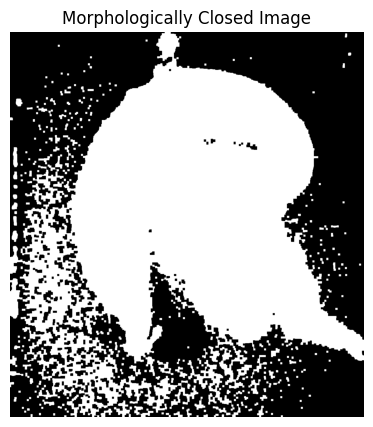

Number of labels in /home/projects/registration/Data/BFI_registration/222/BFI/cropped_222/222/BFI/B_222-ST_BFI-SE_939_original.jpg: 303


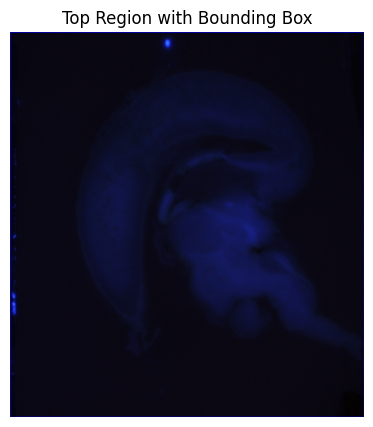

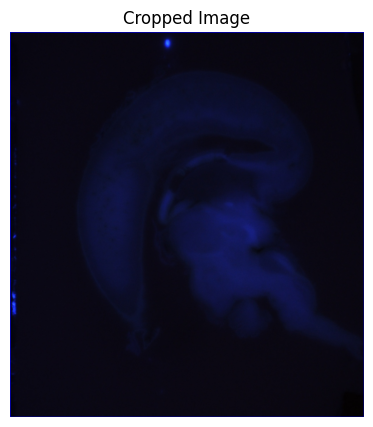

In [67]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import skimage.measure

def process_and_display_image(image_path):
    # Load the image in BGR format
    bgr_image = cv.imread(image_path)
    if bgr_image is None:
        print(f"Error loading image: {image_path}")
        return
    
    # Convert the image to grayscale
    gray = cv.cvtColor(bgr_image, cv.COLOR_BGR2GRAY)
    
    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(bgr_image, cv.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')
    plt.show()

    # Apply threshold
    thres = np.max(gray) - 0.91 * (np.max(gray))
    ret, thresh1 = cv.threshold(gray, thres, np.max(gray), cv.THRESH_BINARY)
    
    # Display the thresholded image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(thresh1, cmap='gray')
    plt.title(f"Thresholded Image (Threshold: {thres:.2f})")
    plt.axis('off')
    plt.show()

    # Apply morphological operations
    element = cv.getStructuringElement(cv.MORPH_RECT, (7, 7))
    dilate1 = cv.dilate(thresh1, element, iterations=1)
    kernel = np.ones((7, 7), np.uint8)
    mask_image_closed = cv.morphologyEx(dilate1, cv.MORPH_CLOSE, kernel)

    # Display the morphologically closed image
    plt.figure(figsize=(10, 5))
    plt.imshow(mask_image_closed, cmap='gray')
    plt.title("Morphologically Closed Image")
    plt.axis('off')
    plt.show()

    # Label the connected components
    labeled_image, count = skimage.measure.label(mask_image_closed, connectivity=2, return_num=True)
    print(f"Number of labels in {image_path}: {count}")
    regions = skimage.measure.regionprops(labeled_image)

    # Sort the regions by area in descending order
    regions.sort(key=lambda x: x.area, reverse=True)

    if len(regions) > 0:
        # Get the bounding box coordinates of the top region
        min_row, min_col, max_row, max_col = regions[0].bbox

        # Draw a rectangle around the detected region
        cv.rectangle(bgr_image, (min_col, min_row), (max_col, max_row), (255, 0, 0), 2)

        # Display the original image with the bounding box
        plt.figure(figsize=(10, 5))
        plt.imshow(cv.cvtColor(bgr_image, cv.COLOR_BGR2RGB))
        plt.title("Top Region with Bounding Box")
        plt.axis('off')
        plt.show()

        # Crop the image using the bounding box coordinates
        cropped_image = bgr_image[min_row:max_row, min_col:max_col]

        # Display the cropped image
        plt.figure(figsize=(5, 5))
        plt.imshow(cv.cvtColor(cropped_image, cv.COLOR_BGR2RGB))
        plt.title("Cropped Image")
        plt.axis('off')
        plt.show()

# Example usage
#image_path = '/home/projects/registration/Data/BFI_registration/222/BFI/fiducial_removed_222/222/BFI/B_222-ST_BFI-SE_939_original.jpg'  # Replace with the path to your image
image_path = '/home/projects/registration/Data/BFI_registration/222/BFI/cropped_222/222/BFI/B_222-ST_BFI-SE_939_original.jpg'  # Replace with the path to your image
process_and_display_image(image_path)


# Cropped image resized - keep at top left

In [ ]:
#below function is to get the largest dimension and apply it to all the images in cropped images
# move the images to top-left
def find_largest_dimension(input_folder):
    max_height = 0
    max_width = 0

    for image_filename in os.listdir(input_folder):
        if image_filename.endswith('.jpg'):
            image_path = os.path.join(input_folder, image_filename)
            image = cv.imread(image_path)
            height, width = image.shape[:2]
            if height > max_height:
                max_height = height
            if width > max_width:
                max_width = width

    return max_height, max_width

def resize_and_pad_image(image, target_height, target_width):
    height, width = image.shape[:2]
    padded_image = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    padded_image[:height, :width] = image
    return padded_image

def process_folder(input_folder, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Find the largest dimension in the input folder
    max_height, max_width = find_largest_dimension(input_folder)
    print(f"Largest dimension found: {max_height}x{max_width}")

    # Process each image in the input folder
    for image_filename in os.listdir(input_folder):
        if image_filename.endswith('.jpg'):
            image_path = os.path.join(input_folder, image_filename)
            image = cv.imread(image_path)

            # Resize and pad the image
            padded_image = resize_and_pad_image(image, max_height, max_width)

            # Save the padded image in the output folder
            output_image_path = os.path.join(output_folder, image_filename)
            cv.imwrite(output_image_path, padded_image)
            print(f"Processed and saved: {output_image_path}")
biosampleid = 222
series = 'BFI' 
# 
input_folder = os.path.join('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/cropped' , str(biosampleid), series)
output_folder = os.path.join('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/222_PREPROCESS_Data/cropped_Resize' , str(biosampleid), series)
process_folder(input_folder, output_folder)


# Errors while running stack_bfi_update.py code

In [ ]:
# HEM1 
# AttributeError: 'NoneType' object has no attribute 'params'. 
# to the above error solution took is to drop the image slices when None value is returned and 
# continue with next images.


# HEM 2
# Registration is happening till 36%. 
# showing the error as 'Registration failed: ratio exceeded tolerance'
# the tolerance value is set to : rmse_offset_tol=1.05


# Concatenation of the two hemisphers got by stack_bfi_updated.py file

In [25]:
import nrrd
# Read the two NRRD images
hem1 = sitk.ReadImage('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/hbp_image_computing1/_out1/BFI_h_1_slab_-1.nrrd')
hem2 = sitk.ReadImage('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/hbp_image_computing1/_out1/BFI_h_2_slab_-1.nrrd')

# Convert SimpleITK images to NumPy arrays
im_arr1 = sitk.GetArrayFromImage(hem1)
im_arr2 = sitk.GetArrayFromImage(hem2)
print('im_arr1 shape: ',im_arr1.shape)
print('im_arr2 shape: ',im_arr2.shape)

im_arr1 shape:  (882, 506, 519)
im_arr2 shape:  (296, 506, 519)


In [19]:
# Transpose the arrays if needed (to match the desired orientation)
im_array_1 = np.transpose(im_arr1, (0, 2, 1))
print(im_array_1.shape)

(882, 519, 506)


In [20]:
im_array_2 = np.transpose(im_arr2, (0, 2, 1))
print(im_array_2.shape)

(296, 519, 506)


In [22]:
# Reverse the second image along the z-axis
im1_arr_rev = im_array_2[::-1, :, :]
print(im1_arr_rev.shape)


(296, 519, 506)


In [23]:

# Concatenate the reversed image with the first image along the z-axis
concat = np.concatenate((im1_arr_rev, im_array_1), axis=0)


In [26]:

# Save the concatenated array as an NRRD file
nrrd.write('/home/projects/registration/athira/mytest/PHASE_2/Week7_222_Brain/hbp_image_computing1/_out1/concat_222_brain', concat)

print("Concatenated NRRD file saved as 'concat_222_brain.nrrd'")

Concatenated NRRD file saved as 'concat_222_brain.nrrd'
